In [ ]:
#Downloads the anime dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

path = kagglehub.dataset_download(
    "nalisha/anime-dataset-ratings-genres-and-popularity"
)

print(path)

100%|██████████| 6.55M/6.55M [00:00<00:00, 17.7MB/s]

Extracting files...


C:\Users\Andrew\.cache\kagglehub\datasets\nalisha\anime-dataset-ratings-genres-and-popularity\versions\1


In [1]:
#Import using pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/anime_dataset.csv")
print(df.columns)

Index(['mal_id', 'title', 'title_english', 'title_japanese', 'type', 'source',
       'episodes', 'status', 'airing', 'aired_from', 'aired_to', 'duration',
       'rating', 'score', 'scored_by', 'rank', 'popularity', 'members',
       'favorites', 'season', 'year', 'studios', 'producers', 'licensors',
       'genres', 'themes', 'demographics', 'synopsis', 'image_url'],
      dtype='str')


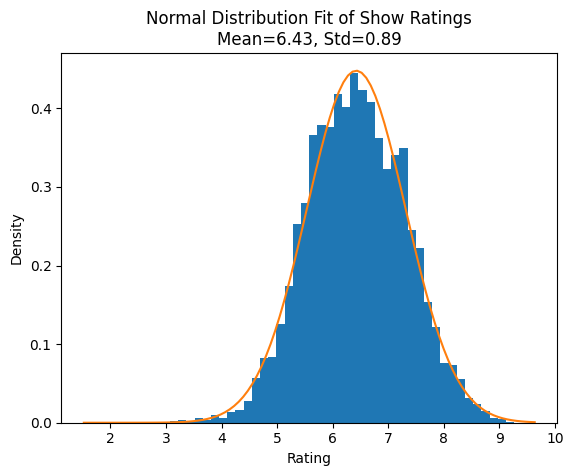

In [6]:
from scipy.stats import norm
score = df["score"].dropna()

plt.hist(score,bins=50,density=True)
mu, std = norm.fit(score)

xmin, xmax = plt.xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,mu,std)

plt.plot(x,p)

plt.title(f"Normal Distribution Fit of Show Ratings\nMean={mu:.2f}, Std={std:.2f}")

plt.xlabel("Rating")
plt.ylabel("Density")

plt.show()

In [16]:
from scipy import stats

anime_rating_mean = np.mean(score)
anime_rating_median = np.median(score)
anime_rating_mode = stats.mode(score)
mode_val = anime_rating_mode.mode

print(anime_rating_mean)
print(anime_rating_median)
print(mode_val)

# Mean = Median = Mode Normal distribution, not skewed left or right
# If right skew then a few higher ratings are pulling mean higher
# If left skew then a few lower ratings are pulling mean lower


6.425589684295194
6.41
6.43


In [ ]:
# Determine whether data is within 68% of 1 SD
std = np.std(score)

upper_bound = anime_rating_mean + std
lower_bound = anime_rating_mean - std

total_count = np.count_nonzero(score) # Total Population size
in_range_count = np.count_nonzero((score <= upper_bound) & (score >= lower_bound)) # Count of entries within the range of std

percent_within_std = (in_range_count/total_count) * 100 

print(f"{percent_within_std:.2f}%") # Close to 68% thus meaning normal data?



67.87%


In [24]:
bottom_5 = np.percentile(score,5)
top_5 = np.percentile(score,95)
print(bottom_5, top_5)

print(df.title[(df.score <= bottom_5)])
print(df.title[(df.score >= top_5)])


5.01 7.88
91                                 Chou Henshin Cosprayers
387                                        Hametsu no Mars
563                                          Legend of Duo
650      Chou Henshin Cosprayers vs. Ankoku Uchuu Shoug...
670                               Houkago no Shokuinshitsu
                               ...                        
27831                                       Twins Hinahima
29697    Mamonogurai no Boukensha: Ore dake Mamono wo K...
29698    Mamonogurai no Boukensha: Ore dake Mamono wo K...
29780                     Daikenja Riddle no Jikan Gyakkou
29781                     Daikenja Riddle no Jikan Gyakkou
Name: title, Length: 1002, dtype: str
0                            Cowboy Bebop
1         Cowboy Bebop: Tengoku no Tobira
2                                  Trigun
5                            Eyeshield 21
6                    Hachimitsu to Clover
                       ...               
29184    Dr. Stone: Science Future Part 3
29412    